In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "lines.linewidth": 0.5,
    "figure.dpi": 300,
    "savefig.bbox": "tight",
    "grid.alpha": 0.3,
})

palette_colors = ["#A1C9F4", "#A1D99B"] # blue (Baseline) and green (Optimized)

In [6]:
def load_objective_data(path_baseline, path_optimized):
    """Carga los JSON y devuelve un DataFrame con el gap relativo listo para Seaborn."""
    with open(path_baseline, 'r') as f:
        baseline_data = {inst["instance"]: [run["objective"] for run in inst["runs"]] for inst in json.load(f)}
    
    with open(path_optimized, 'r') as f:
        optimized_data = {inst["instance"]: [run["objective"] for run in inst["runs"]] for inst in json.load(f)}

    instances = sorted(set(baseline_data) & set(optimized_data))
    records = []

    for inst in instances:
        base = np.array(baseline_data[inst])
        opt = np.array(optimized_data[inst])

        # Calcular gap relativo respecto a la media del baseline
        base_ref = base.mean()
        base_gap = (base - base_ref) / base_ref
        opt_gap = (opt - base_ref) / base_ref

        for val in base_gap:
            records.append({"Instance": inst, "Relative Gap": val, "Method": "Baseline"})
        for val in opt_gap:
            records.append({"Instance": inst, "Relative Gap": val, "Method": "Optimized"})

    return pd.DataFrame(records)


def load_time_data(default_files, tuned_files):
    """Carga los JSON de tiempo y devuelve un DataFrame con los tiempos de ejecución."""
    def extract_time(paths):
        data = {}
        for path in paths:
            with open(path, "r") as f:
                content = json.load(f)
            for inst in content:
                name = inst["instance"]
                if name not in data:
                    data[name] = []
                data[name].extend(run["time"] for run in inst["runs"])
        return data

    default_data = extract_time(default_files)
    tuned_data = extract_time(tuned_files)

    instances = sorted(set(default_data) & set(tuned_data))
    records = []

    for inst in instances:
        for val in default_data[inst]:
            records.append({"Instance": inst, "Execution Time (s)": val, "Method": "Baseline"})
        for val in tuned_data[inst]:
            records.append({"Instance": inst, "Execution Time (s)": val, "Method": "Optimized"})

    return pd.DataFrame(records)

In [7]:
def plot_boxplot_seaborn(df, output_file):
    """1. Genera un Boxplot del gap relativo por instancia."""
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(
        data=df,
        x="Instance",
        y="Relative Gap",
        hue="Method",
        palette=palette_colors,
        boxprops=dict(edgecolor="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
        flierprops=dict(marker="o", markersize=3, markerfacecolor="gray")
    )

    plt.axhline(0, linestyle="--", color="black", alpha=0.6, linewidth=1)
    
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Relative gap (objective value)")
    plt.xlabel(None)
    
    # Arreglar la leyenda para quitar el título ("Method")
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=labels, title=None)

    plt.tight_layout()
    plt.savefig(output_file)
    plt.show()

def plot_ribbon_seaborn(df, output_file):
    """2. Genera un Ribbon plot (Lineplot + Franja de SD) para el tiempo de ejecución."""
    plt.figure(figsize=(7, 4))
    
    sns.lineplot(
        data=df,
        x="Instance",
        y="Execution Time (s)",
        hue="Method",
        style="Method",
        markers=True,
        dashes=False,
        errorbar="sd", # Calcula automáticamente la Desviación Estándar para crear la franja
        palette=palette_colors
    )

    plt.xticks(rotation=45, ha="right")
    plt.xlabel(None)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=labels, title=None)

    plt.tight_layout()
    plt.savefig(output_file)
    plt.show()

def plot_barplot_seaborn(df, output_file):
    """3. Genera un Barplot (+ errorbars) para el tiempo de ejecución."""
    plt.figure(figsize=(7, 4))
    
    sns.barplot(
        data=df,
        x="Instance",
        y="Execution Time (s)",
        hue="Method",
        errorbar="sd", # Barras de error basadas en la Desviación Estándar
        capsize=0.1,
        palette=palette_colors,
        edgecolor="black",
        err_kws={'color': 'black', 'linewidth': 1}
    )

    plt.xticks(rotation=45, ha="right")
    plt.xlabel(None)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=labels, title=None)

    plt.tight_layout()
    plt.savefig(output_file)
    plt.show()

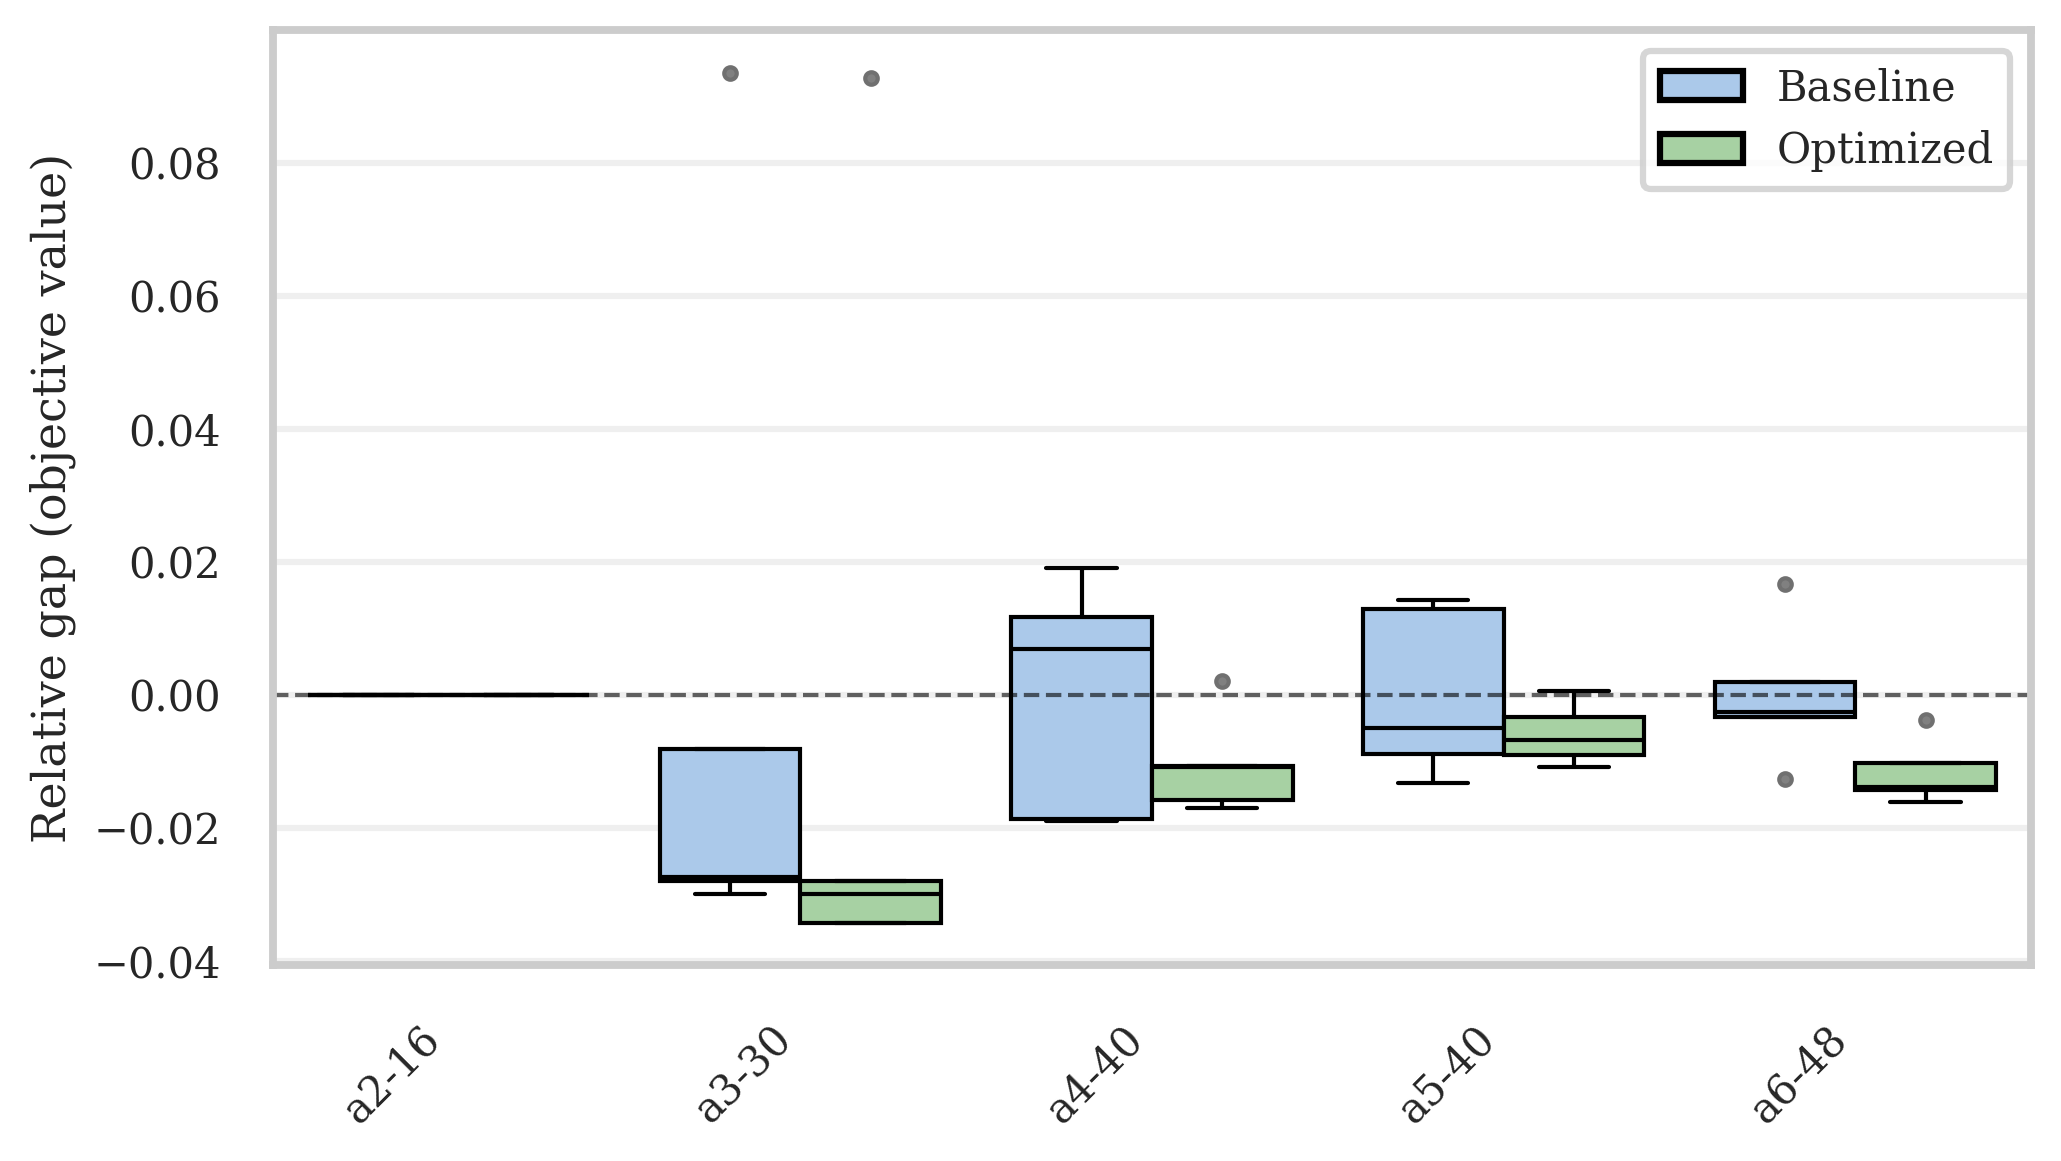

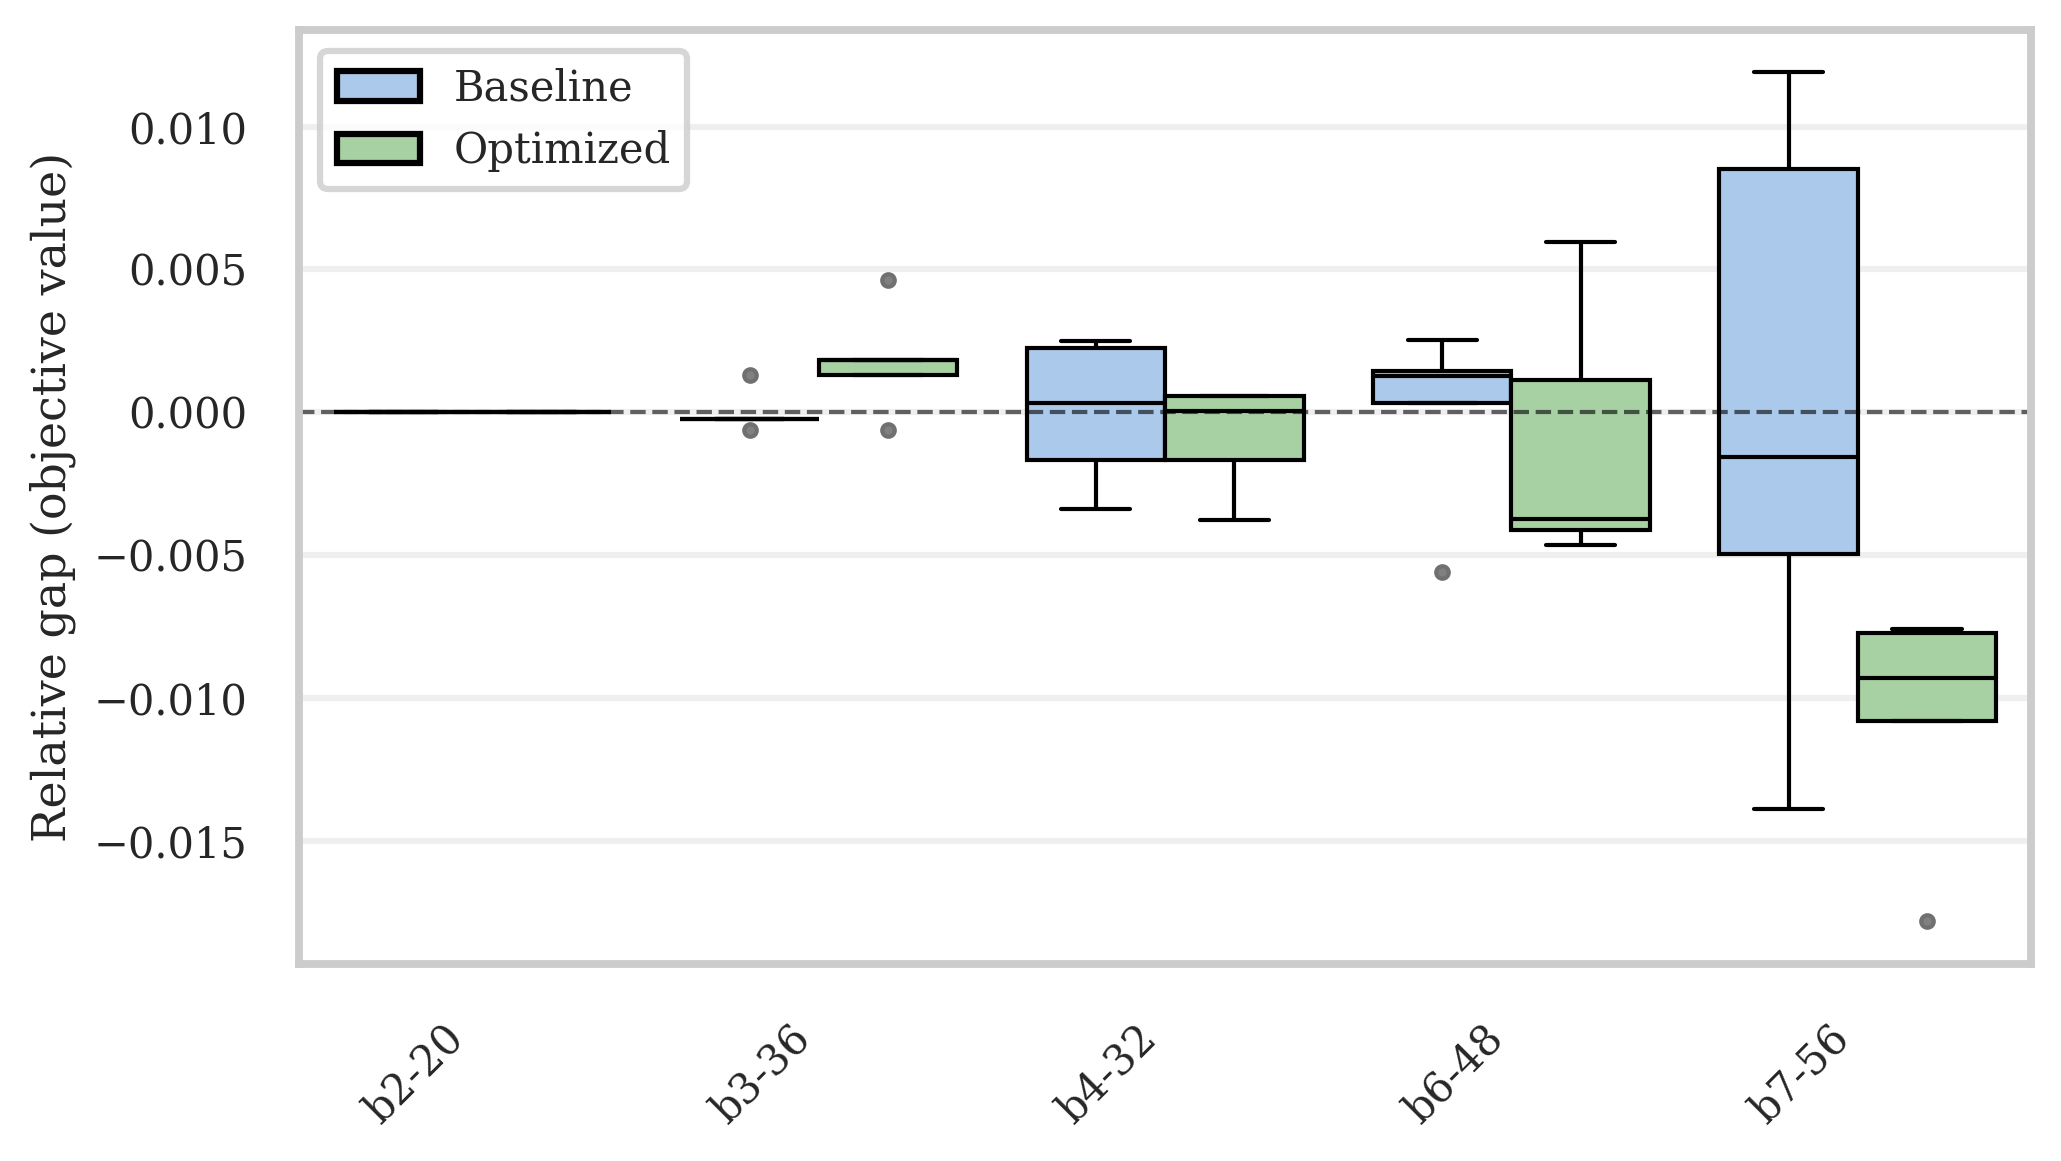

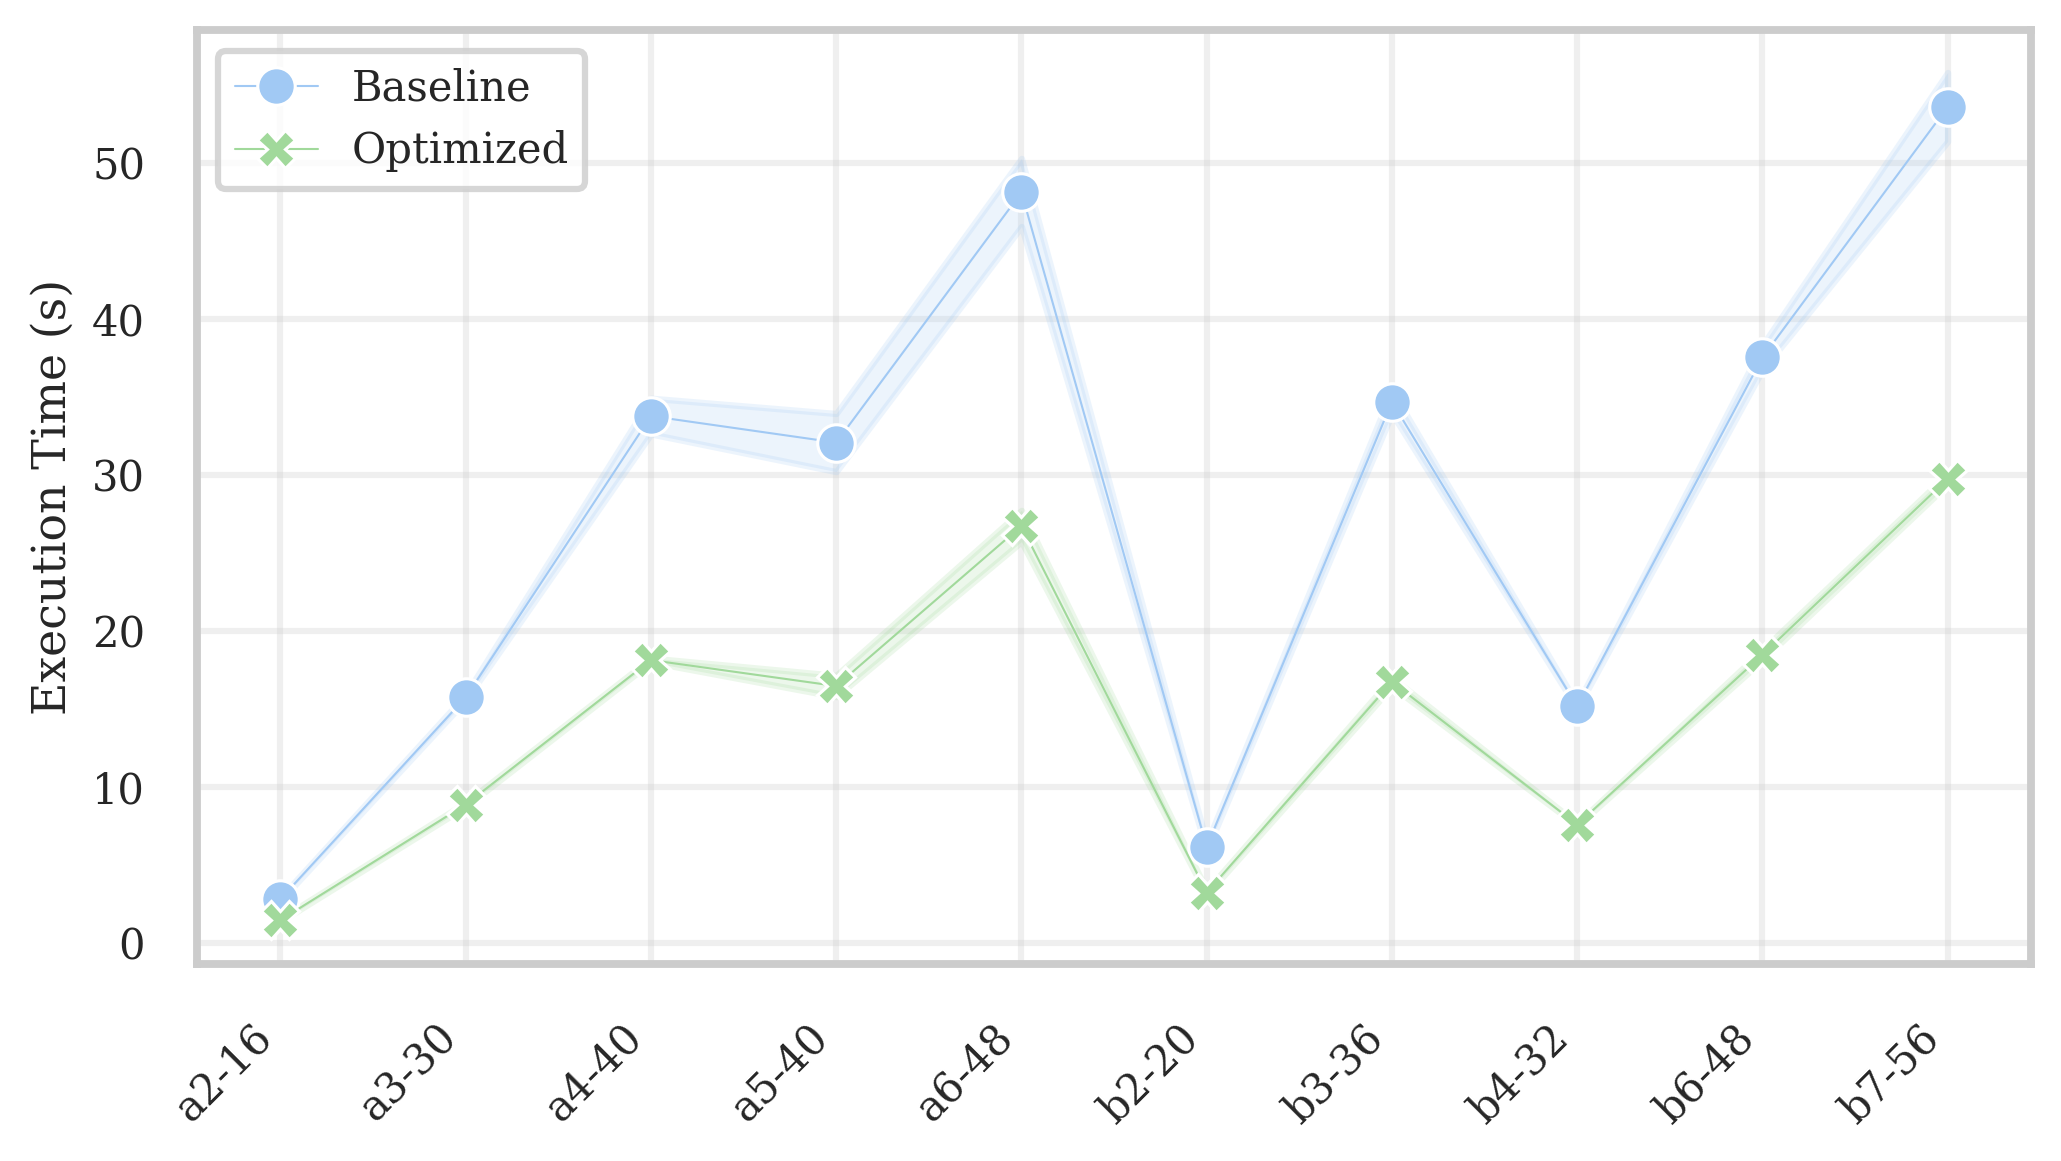

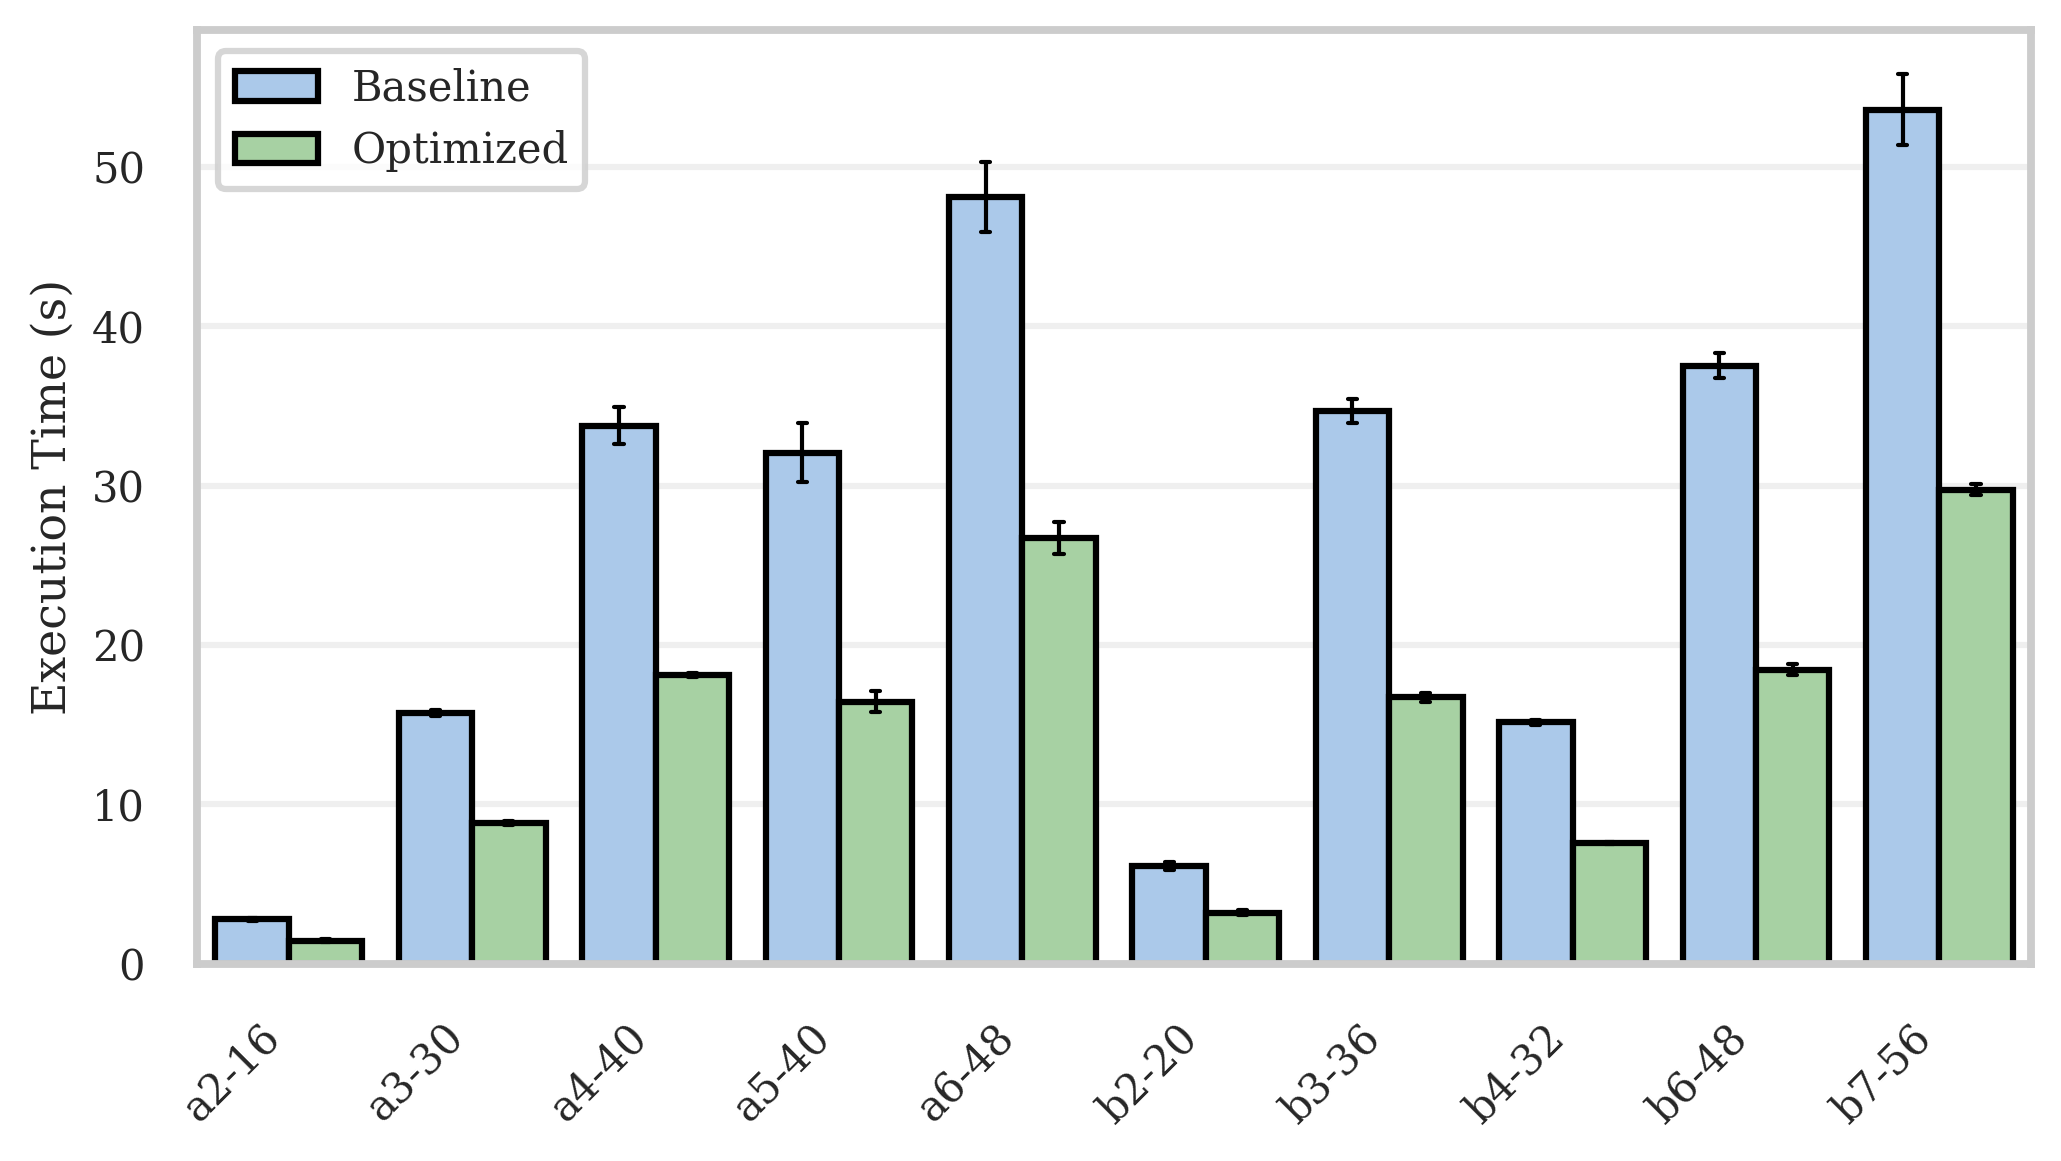

In [8]:
# Rutas a tus archivos
ruta_base = "/home/guillem/TFG-Guillem/scripts/"

path_a0 = f"{ruta_base}results_a0.json"
path_a1 = f"{ruta_base}results_a1.json"
path_b0 = f"{ruta_base}results_b0.json"
path_b1 = f"{ruta_base}results_b1.json"

# 1. Gráficas Boxplot (Gap Relativo)
df_gap_a = load_objective_data(path_a0, path_a1)
plot_boxplot_seaborn(df_gap_a, "relative_gap_boxplot_A.pdf")

df_gap_b = load_objective_data(path_b0, path_b1)
plot_boxplot_seaborn(df_gap_b, "relative_gap_boxplot_B.pdf")

# 2. Preparar el DataFrame de Tiempo para Ribbon y Barplot
df_time = load_time_data(
    default_files=[path_a0, path_b0],
    tuned_files=[path_a1, path_b1]
)

# 3. Gráfica Ribbon Plot original (Tiempo de Ejecución)
plot_ribbon_seaborn(df_time, "time_ribbon.pdf")

# 4. NUEVA: Gráfica Barplot (Tiempo de Ejecución)
plot_barplot_seaborn(df_time, "time_barplot.pdf")